In [1]:
import numpy as np
from scipy import stats
import matplotlib as mpl
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import axes3d 
from matplotlib import cm
import math
import seaborn as sns
from scipy import stats
plt.rc('font', family='SimHei', size=13)
mpl.rcParams['axes.unicode_minus']=False
plt.rcParams['font.sans-serif'] = [u'SimHei']

### 伯努利分布
+  二项分布n=1 时的特殊情况

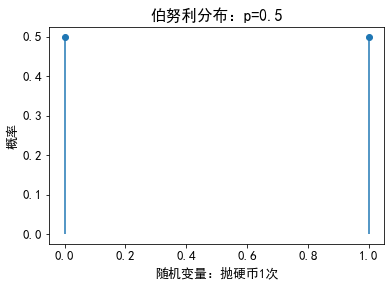

In [2]:
#抛硬币实验，0为负，1为正
x = np.arange(0, 2, 1) 
p = 0.5
p_list = stats.bernoulli.pmf(x, p)

plt.plot(x, p_list, marker='o', linestyle='None')
plt.vlines(x, ymin=0, ymax=p_list)
plt.xlabel('随机变量：抛硬币1次')
plt.ylabel('概率')
plt.title('伯努利分布：p=' + str(p))
plt.show()

### 二项分布
+ 某事件发生的概率为p，独立重复N次实验，该事件发生次数X 的概率分布是二项分布
+ 记为 $ X \thicksim B(n,p) $ 
+ 概率密度函数为 $ P(X=k)=C_n^k p^k (1-p)^{n-k} $

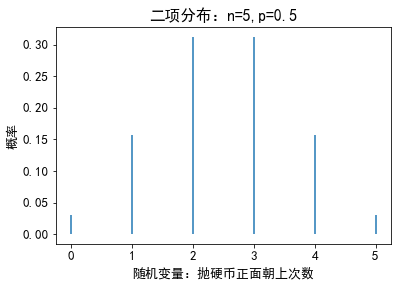

In [3]:
#进行五次抛硬币实验
n = 5
p = 0.5
x = np.arange(0, n+1, 1)

p_list = stats.binom.pmf(x, n, p)
plt.vlines(x, ymin=0, ymax=p_list)
plt.xlabel('随机变量：抛硬币正面朝上次数')
plt.ylabel('概率')
plt.title('二项分布：n=' + str(n) + ',p=' + str(p))
plt.show()


### 多项分布
+ https://yq.aliyun.com/articles/104757


### 几何分布
+ 在重复多次的伯努利试验中，试验进行到某种结果出现第一次为止，此时的试验总次数服从几何分布

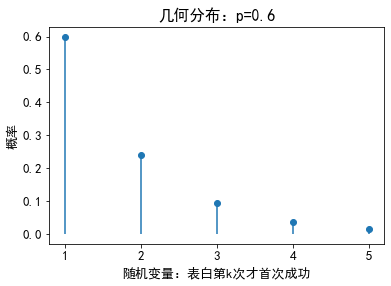

In [4]:
#第k次才实验成功的概率
k = 5
p = 0.6
x = np.arange(1, k+1, 1)

p_list = stats.geom.pmf(x, p)
plt.plot(x, p_list, marker='o', linestyle='None')
plt.vlines(x, ymin=0, ymax=p_list)
plt.xlabel('随机变量：表白第k次才首次成功')
plt.ylabel('概率')
plt.title('几何分布：p=' + str(p))
plt.show()

### 泊松分布
+ 泊松分布可以用来表示独立随机事件发生的次数
+ 例如 某个公交站台一个小时内出现了的公交车的数量 就用泊松分布来表示

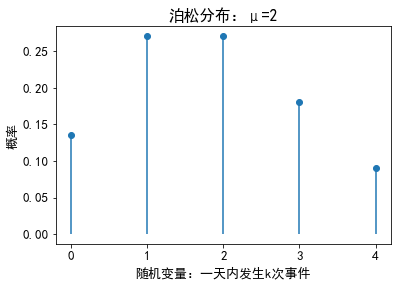

In [5]:
mu = 2
k = 4
x = np.arange(0, k+1, 1)

p_list = stats.poisson.pmf(x, mu)
plt.plot(x, p_list, marker='o', linestyle='None')
plt.vlines(x, 0, p_list)
plt.xlabel('随机变量：一天内发生k次事件')
plt.ylabel('概率')
plt.title('泊松分布：μ='+ str(mu))
plt.show()

### 指数分布
+ 指数分布可以用来表示独立随机事件发生的时间间隔
+ 例如 某个公交站台任意两辆公交车出现的间隔时间 就用指数分布来表示

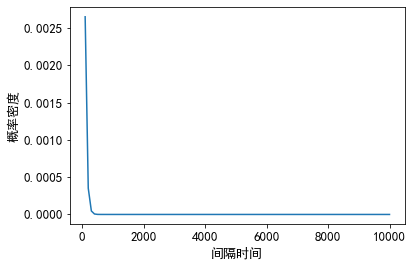

In [6]:
r = 1/50
X = []
Y = []
for x in np.linspace(0, 10000, 100):
    if x==0:
        continue
    p = stats.expon.pdf(x, scale=1/r)  # scale参数是标准差
    X.append(x)
    Y.append(p)
plt.plot(X,Y)
plt.xlabel("间隔时间")
plt.ylabel("概率密度")
plt.show()

### $\Gamma$ 分布
+ $\Gamma$ 函数 与 $\Gamma$ 分布 https://cosx.org/2013/01/lda-math-gamma-function
+ 假设X1, X2, ... Xn 为连续发生事件的等候时间，且这n次等候时间为独立的，那么这n次等候时间之和Y (Y=X1+X2+...+Xn)服从伽玛分布，即 Y~Gamma(α , β), 其中α = n, β = λ， 这里的 λ 是连续发生事件的平均发生频率
+ 指数分布是伽玛分布α = 1的特殊情况

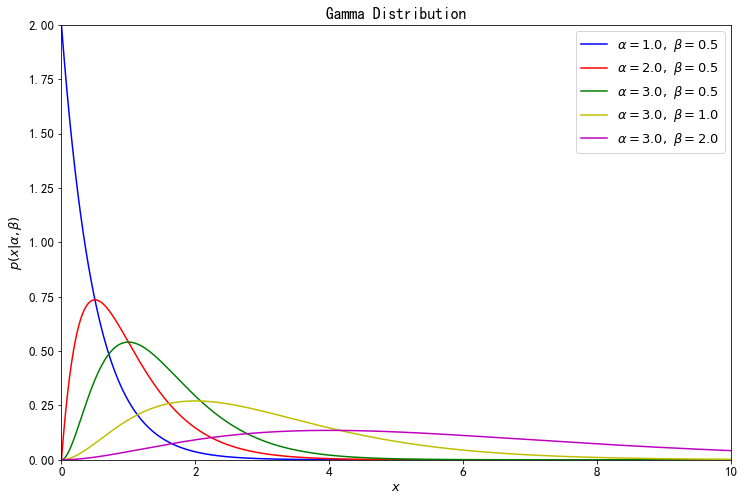

In [7]:
alpha_values = [1, 2, 3, 3, 3]
beta_values = [0.5, 0.5, 0.5, 1, 2]
color = ['b','r','g','y','m']
x = np.linspace(1E-6, 10, 1000)
fig, ax = plt.subplots(figsize=(12, 8))
for k, t, c in zip(alpha_values, beta_values, color):
    dist = stats.gamma(k, 0, t)
    plt.plot(x, dist.pdf(x), c=c, label=r'$\alpha=%.1f,\ \beta=%.1f$' % (k, t))
plt.xlim(0, 10)
plt.ylim(0, 2)
plt.xlabel('$x$')
plt.ylabel(r'$p(x|\alpha,\beta)$')
plt.title('Gamma Distribution')
plt.legend(loc=0)
plt.show()

### Beta 分布
+ Beta分布是一组定义在区间\[0, 1\]的连续概率分布，有两个参数α 和β ，且α,β>0
+ 概率密度函数为
$$
B e t a(p \mid a, \beta)=\frac{\Gamma(a+\beta)}{\Gamma(a) \Gamma(\beta)} p^{a-1}(1-p)^{\beta-1}
$$

https://zhuanlan.zhihu.com/p/37976562

No handles with labels found to put in legend.
[0.5, 0.5]
[5, 1]
[1, 3]
[2, 2]
[2, 5]


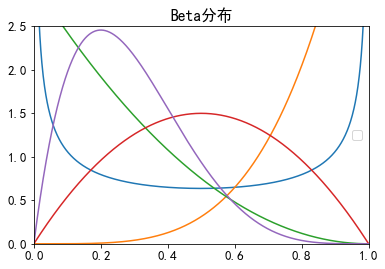

In [8]:

# 定义一组alpha 跟 beta值
alpha_beta_values = [[0.5,0.5], [5, 1], [1,3], [2,2], [2,5]]
linestyles = []

# 定义 x 值
x = np.linspace(0, 1, 1002)[1:-1]
for alpha_beta_value in alpha_beta_values:
  print(alpha_beta_value)
  dist = stats.beta(alpha_beta_value[0], alpha_beta_value[1])
  dist_y = dist.pdf(x)
  # 添加图例
  # plot.legend('alpha=')
  # 创建 beta 曲线
  plt.plot(x, dist_y)

# 设置标题
plt.title(u'Beta分布')
# 设置 x,y 轴取值范围
plt.xlim(0, 1)
plt.ylim(0, 2.5)
plt.legend()
plt.show()

### t-分布
+ t分布的极限是正太分布
+ $h(t)=\frac{\Gamma\left(\frac{n+1}{2}\right)}{\sqrt{\pi n} \Gamma\left(\frac{n}{2}\right)}\left(1+\frac{t^{2}}{n}\right)^{-\frac{n+1}{2}},-\infty<t<+\infty$

Text(0.5, 1.0, 't分布的概率密度函数')

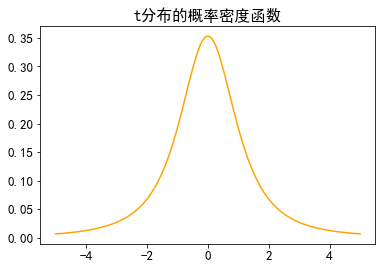

In [9]:
x = np.linspace(-5,5,100)
y = stats.t.pdf(x,2)
plt.plot(x,y,c="orange")
plt.title('t分布的概率密度函数')

### 卡方分布
+ $f(u)=\frac{1}{\Gamma\left(\frac{v}{2}\right) 2^{\frac{v}{2}}} u^{\frac{\nu}{2}-1} e^{-\frac{u}{2}}, 0 \leq u<\infty$

Text(0.5, 1.0, '卡方分布')

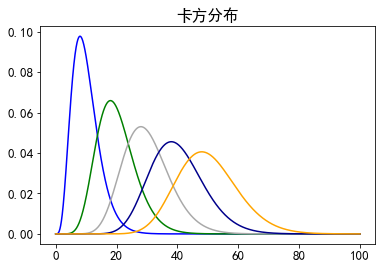

In [10]:
x = np.linspace(0,100,100000)
color = ["blue","green","darkgrey","darkblue","orange"]
for i in range(10,51,10):
    y=stats.chi2.pdf(x,df=i)
    plt.plot(x,y,c=color[int((i-10)/10)])
plt.title('卡方分布')

In [11]:
### Dirichlet

In [12]:
from scipy.stats import dirichlet
# quantiles = np.array([0.2, 0.2, 0.6])  # specify quantiles
# alpha = np.array([0.4, 5, 15])  # specify concentration parameters
# dirichlet.pdf(quantiles, alpha)

# x = np.linspace(0,100,100000)
# # color = ["blue","green","darkgrey","darkblue","orange"]

# y=stats.dirichlet.pdf(x,alpha=[0.5, 4, 18])
# plt.plot(x,y,c='blue')
# # plt.plot(x,y,c='green')

# plt.title('卡方分布')

quantiles = np.array([0.2, 0.2, 0.6])  # specify quantiles
alpha = np.array([0.4, 5, 15])  # specify concentration parameters
dirichlet.pdf(quantiles, alpha)

0.2843831684937255

### 正太分布/高斯分布
+ 随机变量 X 服从一个期望为 $\mu$， 标准方差为 $\sigma^2$的高斯分布 
+ 记为 $X \sim N\left(\mu, \sigma^{2}\right)$
+ 概率密度函数 $f(x)=\frac{1}{\sigma \sqrt{2 \pi}} e^{-\frac{(x-\mu)^{2}}{2 \sigma^{2}}}$
+ $\mu$ = 0, $\sigma$ = 1 的情况为标准正态分布

Text(0.5, 1.0, '正态分布的概率密度函数')

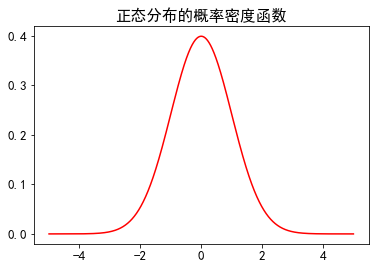

In [13]:
x = np.linspace(-5,5,100000)
y = stats.norm.pdf(x,0,1)
plt.plot(x,y,c="red")
plt.title(u'正态分布的概率密度函数')

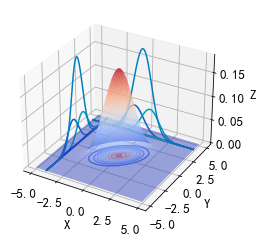

In [14]:
### 二维正太分布
num = 200
l = np.linspace(-5,5,num)
X,Y = np.meshgrid(l,l)

u = np.array([0,0]) #均值
o = np.array([[1,0.5],[0.5,1]])  #协方差矩阵

pos = np.concatenate((np.expand_dims(X,axis=2),np.expand_dims(Y,axis=2)),axis=2)  #定义坐标点

a = np.dot((pos-u),np.linalg.inv(o))  #o的逆矩阵
b = np.expand_dims(pos-u,axis=3)
# Z = np.dot(a.reshape(200*200,2),(pos-u).reshape(200*200,2).T)
Z = np.zeros((num,num),dtype=np.float32)                
for i in range(num):
    Z[i] = [np.dot(a[i,j],b[i,j]) for j in range(num)]                         #计算指数部分

Z = np.exp(Z*(-0.5))/(2*np.pi*math.sqrt(np.linalg.det(o)))

fig = plt.figure()                                                              #绘制图像
ax = fig.add_subplot(111,projection='3d')
ax.plot_surface(X,Y,Z,rstride=2,cstride=2,alpha=0.6,cmap=cm.coolwarm)

cset = ax.contour(X,Y,Z,10,zdir='z',offset=0,cmap=cm.coolwarm)                     #绘制xy面投影
cset = ax.contour(X,Y,Z,zdir = 'x',offset=-4,cmap = mpl.cm.winter)                 #绘制zy面投影
cset = ax.contour(X,Y,Z,zdir = 'y',offset= 4,cmap =mpl.cm.winter)                  #绘制zx面投影

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

plt.show()

### Reference
+ https://my.oschina.net/u/2245781/blog/1853847
+ gamma beta dirchelt 分布 demo https://www.pythonf.cn/read/57755
+ https://zhuanlan.zhihu.com/p/37976562